In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#guided

#import data

df = pd.read_csv('movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [72]:
#check for missing data

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [73]:
#Shape and structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [74]:
#summary statistics
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


In [75]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.columns.tolist()

Rows: 7,668 | Columns: 15


['name',
 'rating',
 'genre',
 'year',
 'released',
 'score',
 'votes',
 'director',
 'writer',
 'star',
 'country',
 'budget',
 'gross',
 'company',
 'runtime']

In [76]:
df.isnull().sum()


name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [77]:
df['budget'] = df['budget'].fillna(df['budget'].median())
df['gross'] = df['gross'].fillna(df['gross'].median())
df['runtime'] = df['runtime'].fillna(df['runtime'].median())
df['score'] = df['score'].fillna(df['score'].median())
df['votes'] = df['votes'].fillna(df['votes'].median())

df['rating'] = df['rating'].fillna('Not Rated')
df['writer'] = df['writer'].fillna('Unknown')
df['star'] = df['star'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['company'] = df['company'].fillna('Unknown')

df = df.dropna(subset=['released'])
df.isnull().sum()


name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [78]:
df['score'] = df['score'].astype('float64')
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
df['runtime'] = df['runtime'].astype('int64')
df['votes'] = df['votes'].astype('int64')

In [79]:
df = df.drop('year', axis=1)
df['release_year'] = df['released'].str.extract(r'(\d{4})').astype('int64')
df.head()

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,release_year
0,The Shining,R,Drama,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146,1980
1,The Blue Lagoon,R,Adventure,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124,1980
3,Airplane!,PG,Comedy,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88,1980
4,Caddyshack,R,Comedy,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98,1980


In [80]:
duplicate_count = df.duplicated(subset=['name']).sum()
print(f"Duplicate movie titles found: {duplicate_count}")

df = df.drop_duplicates(subset=['name']).reset_index(drop=True)
df.info()

Duplicate movie titles found: 156
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7510 entries, 0 to 7509
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          7510 non-null   object 
 1   rating        7510 non-null   object 
 2   genre         7510 non-null   object 
 3   released      7510 non-null   object 
 4   score         7510 non-null   float64
 5   votes         7510 non-null   int64  
 6   director      7510 non-null   object 
 7   writer        7510 non-null   object 
 8   star          7510 non-null   object 
 9   country       7510 non-null   object 
 10  budget        7510 non-null   int64  
 11  gross         7510 non-null   int64  
 12  company       7510 non-null   object 
 13  runtime       7510 non-null   int64  
 14  release_year  7510 non-null   int64  
dtypes: float64(1), int64(5), object(9)
memory usage: 880.2+ KB


In [81]:
#We add two derived metrics to the DataFrame - Profit, and ROI

zero_budget = (df['budget'] == 0).sum()
print(f"Movies with $0 budget: {zero_budget}")

df['profit'] = df['gross'] - df['budget']
df['ROI'] = df['gross'] / df['budget']

Movies with $0 budget: 0


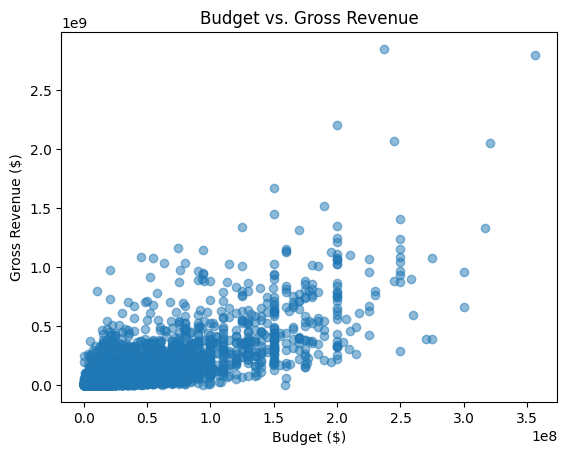

In [82]:
plt.scatter(x=df['budget'], y=df['gross'], alpha=0.5)
plt.title('Budget vs. Gross Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Gross Revenue ($)')
plt.show()

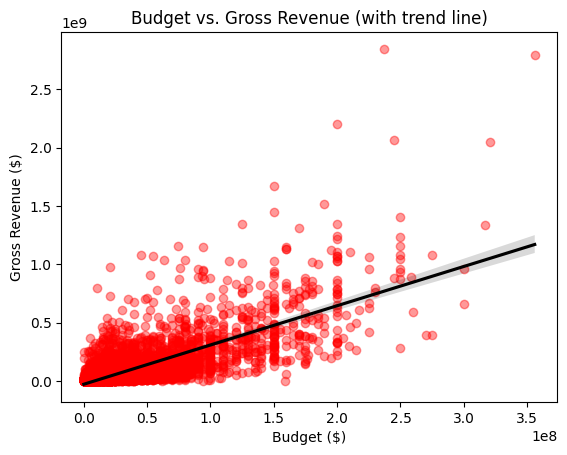

In [83]:
sns.regplot(
    x='budget', y='gross', data=df,
    scatter_kws={"color": "red", "alpha": 0.4},
    line_kws={"color": "black"}
)
plt.title('Budget vs. Gross Revenue (with trend line)')
plt.xlabel('Budget ($)')
plt.ylabel('Gross Revenue ($)')
plt.show()

In [84]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,score,votes,budget,gross,runtime,release_year,profit,ROI
score,1.000000,0.408442,0.060405,0.185241,0.397784,0.111955,0.202591,-0.015032
votes,0.408442,1.000000,0.457898,0.634425,0.305845,0.219127,0.628458,0.010299
budget,0.060405,0.457898,1.000000,0.744204,0.272195,0.281850,0.616630,-0.025628
gross,0.185241,0.634425,0.744204,1.000000,0.245290,0.250245,0.984746,0.012341
runtime,0.397784,0.305845,0.272195,0.245290,1.000000,0.121599,0.218196,-0.031927
release_year,0.111955,0.219127,0.281850,0.250245,0.121599,1.000000,0.221520,0.011107
profit,0.202591,0.628458,0.616630,0.984746,0.218196,0.221520,1.000000,0.021221
ROI,-0.015032,0.010299,-0.025628,0.012341,-0.031927,0.011107,0.021221,1.000000


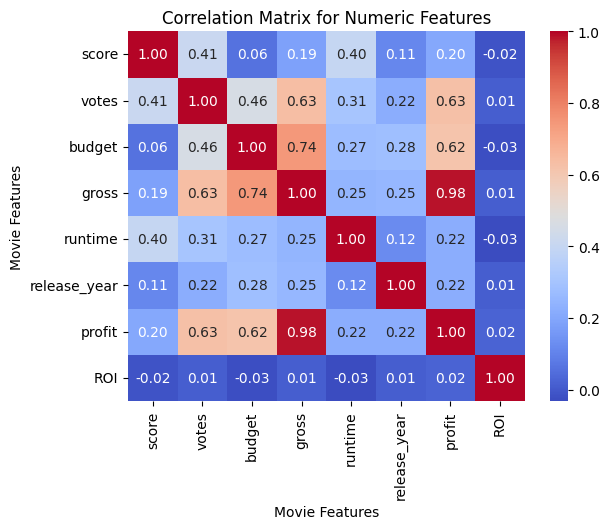

In [85]:
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [86]:
#Top 10 companies by budget
df.groupby('company')[['budget', 'gross', 'profit']].sum() \
    .sort_values(by='budget', ascending=False) \
    .head(10)

,budget,gross,profit
company,,,
Warner Bros.,19841300000,55020849867,35179549867
Universal Pictures,16691630001,51550073949,34858443948
Columbia Pictures,15626107000,41522604959,25896497959
Paramount Pictures,14053950000,39318239706,25264289706
Twentieth Century Fox,11875100000,39159651364,27284551364
Walt Disney Pictures,10204700000,33353754158,23149054158
New Line Cinema,5728200000,19020537245,13292337245
Touchstone Pictures,4543200000,11619875640,7076675640
Metro-Goldwyn-Mayer (MGM),3871750000,8604332138,4732582138


In [87]:
#Most profilic actor
df['star'].value_counts().head(1)


star
Nicolas Cage    42
Name: count, dtype: int64

In [89]:
#Movie with high Gross
df.loc[df['gross'].idxmax(), ['name', 'gross', 'star']]


name              Avatar
gross         2847246203
star     Sam Worthington
Name: 5384, dtype: object

In [90]:
#Most common genre by studio
top_companies = df['company'].value_counts().head(10).index

genre_by_company = (
    df[df['company'].isin(top_companies)]
    .groupby(['company', 'genre'])
    .size()
    .reset_index(name='movie_count')
    .sort_values(['company', 'movie_count'], ascending=[True, False])
)

genre_by_company.loc[genre_by_company.groupby('company')['movie_count'].idxmax()] \
    .sort_values('movie_count', ascending=False) \
    .reset_index(drop=True)



,company,genre,movie_count
0,Universal Pictures,Comedy,132
1,Warner Bros.,Action,125
2,Columbia Pictures,Action,110
3,Paramount Pictures,Comedy,98
4,Twentieth Century Fox,Action,82
5,Touchstone Pictures,Comedy,56
6,New Line Cinema,Comedy,54
7,Metro-Goldwyn-Mayer (MGM),Comedy,45
8,TriStar Pictures,Comedy,38
9,Walt Disney Pictures,Action,31
